## Part 1: Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing.csv')

In [5]:
df.head()

,ID,Address,Sale Price,Sale Date,Type,Beds,Baths,Parking,Land / Size,Air Conditioning,Outdoor Area,LINK
0,PEN001,"5/90 Lethbridge Street, Penrith",581000.0,2026-08-17,Villa,2,1,1,—,NaN,Yes,https://www.realestate.com.au/sold/property-vi...
1,PEN002,"2/165-169 Derby Street, Penrith",510000.0,2026-08-17,Unit,2,1,1,—,Yes,Yes,https://www.realestate.com.au/sold/property-un...
2,PEN003,"1/29 Lethbridge Street, Penrith",567000.0,2026-08-14,Unit,2,2,1,—,Yes,Yes,https://www.realestate.com.au/sold/property-un...
3,PEN004,"2/12 Thurston Street, Penrith",510000.0,2026-08-12,Apartment,2,1,1,—,NaN,Yes,https://www.realestate.com.au/sold/property-ap...
4,PEN005,"5/90-92 Cox Avenue, Penrith",820000.0,2026-08-11,Townhouse,3,2,2,—,NaN,Yes,https://www.realestate.com.au/sold/property-to...


## Part 2: Data Cleaning

In [6]:
df['Sale Price'] = (
    df['Sale Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [7]:
df['Sale Date'] = pd.to_datetime(df['Sale Date'], errors='coerce')

In [8]:
df['Land / Size'] = (
    df['Land / Size']
    .astype(str)
    .str.replace('m²', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace('—', '', regex=False)
    .str.strip()
)
df['Land / Size'] = pd.to_numeric(df['Land / Size'], errors='coerce')

In [9]:
for col in ['Air Conditioning', 'Outdoor Area']:
    df[col] = df[col].astype(str).replace({'nan': np.nan, 'NaN': np.nan, 'NA': np.nan, '—': np.nan})

In [10]:
for col in ['Beds', 'Baths', 'Parking']:
    df[col] = pd.to_numeric(df[col].astype(str).replace('—', np.nan), errors='coerce')

In [11]:
df['LINK'] = df['LINK'].astype(str).str.replace(r'^\d+\.\s*', '', regex=True).str.strip()

In [12]:
df['Suburb'] = df['ID'].str[:3]
df['Type'] = df['Type'].astype('string').str.strip()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ID                105 non-null    object        
 1   Address           105 non-null    object        
 2   Sale Price        105 non-null    float64       
 3   Sale Date         105 non-null    datetime64[ns]
 4   Type              105 non-null    string        
 5   Beds              104 non-null    float64       
 6   Baths             100 non-null    float64       
 7   Parking           82 non-null     float64       
 8   Land / Size       53 non-null     float64       
 9   Air Conditioning  45 non-null     object        
 10  Outdoor Area      78 non-null     object        
 11  LINK              105 non-null    object        
 12  Suburb            105 non-null    object        
dtypes: datetime64[ns](1), float64(5), object(6), string(1)
memory usage: 10.8+ KB


In [14]:
df.describe()

,Sale Price,Sale Date,Beds,Baths,Parking,Land / Size
count,1.050000e+02,105,104.000000,100.000000,82.000000,53.000000
mean,9.042624e+05,2026-07-19 06:24:00,2.000000,1.430000,1.268293,145.545283
min,4.000000e+05,2026-06-02 00:00:00,1.000000,1.000000,1.000000,48.000000
25%,5.880000e+05,2026-07-06 00:00:00,1.000000,1.000000,1.000000,72.000000
50%,6.800000e+05,2026-07-23 00:00:00,2.000000,1.000000,1.000000,101.000000
75%,9.200000e+05,2026-08-03 00:00:00,2.000000,2.000000,1.000000,136.000000
max,3.530000e+06,2026-08-17 00:00:00,5.000000,3.000000,6.000000,807.000000
std,5.836945e+05,NaN,0.800485,0.536637,0.703585,159.551092


In [100]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().mean() * 100).round(2)
})
missing.sort_values('Missing %', ascending=False)

,Missing Count,Missing %
Air Conditioning,60,57.14
Land / Size,52,49.52
Outdoor Area,27,25.71
Parking,23,21.90
Baths,5,4.76
Beds,1,0.95
ID,0,0.00
Address,0,0.00
Sale Price,0,0.00
Sale Date,0,0.00


In [101]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate IDs:', df['ID'].duplicated().sum())
print('Duplicate links:', df['LINK'].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0
Duplicate links: 0


In [102]:
df[['Sale Price', 'Beds', 'Baths', 'Parking', 'Land / Size']].describe().round(2)

,Sale Price,Beds,Baths,Parking,Land / Size
count,105.00,104.0,100.00,82.00,53.00
mean,904262.38,2.0,1.43,1.27,145.55
std,583694.52,0.8,0.54,0.70,159.55
min,400000.00,1.0,1.00,1.00,48.00
25%,588000.00,1.0,1.00,1.00,72.00
50%,680000.00,2.0,1.00,1.00,101.00
75%,920000.00,2.0,2.00,1.00,136.00
max,3530000.00,5.0,3.00,6.00,807.00


## Part 2: Exploratory Data Analysis

In [103]:
df.groupby('Suburb')['Sale Price'].agg(['count', 'mean', 'median', 'min', 'max']).round(2)

,count,mean,median,min,max
Suburb,,,,,
PAR,35,628200.00,626000.0,400000.0,880000.0
PEN,35,714428.57,628000.0,420000.0,1670000.0
SUR,35,1370158.57,1055000.0,621050.0,3530000.0


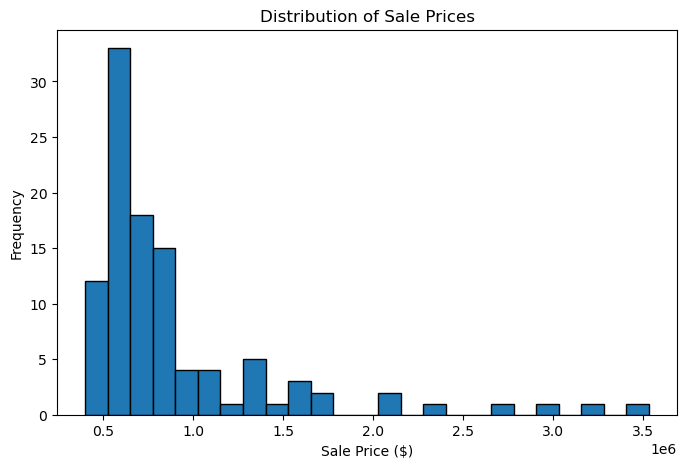

In [104]:
fig, ax = plt.subplots(figsize=(8, 5))
df['Sale Price'].plot(kind='hist', bins=25, ax=ax, edgecolor='black')
ax.set_xlabel('Sale Price ($)')
ax.set_title('Distribution of Sale Prices')
plt.show()

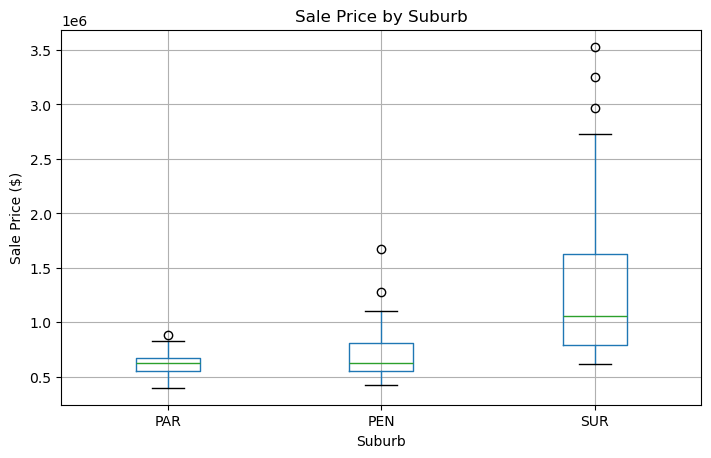

In [105]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='Sale Price', by='Suburb', ax=ax)
ax.set_ylabel('Sale Price ($)')
ax.set_title('Sale Price by Suburb')
plt.suptitle('')
plt.show()

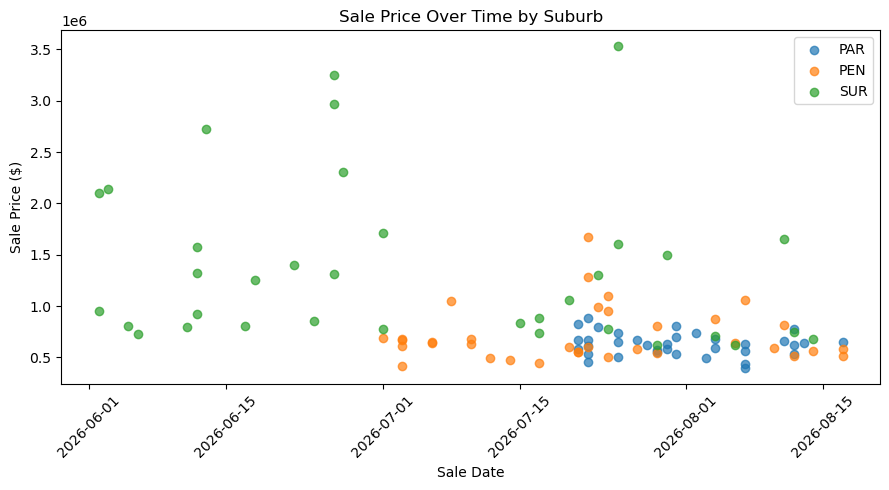

In [106]:
fig, ax = plt.subplots(figsize=(9, 5))
for suburb, group in df.groupby('Suburb'):
    ax.scatter(group['Sale Date'], group['Sale Price'], label=suburb, alpha=0.7)
ax.set_xlabel('Sale Date')
ax.set_ylabel('Sale Price ($)')
ax.set_title('Sale Price Over Time by Suburb')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

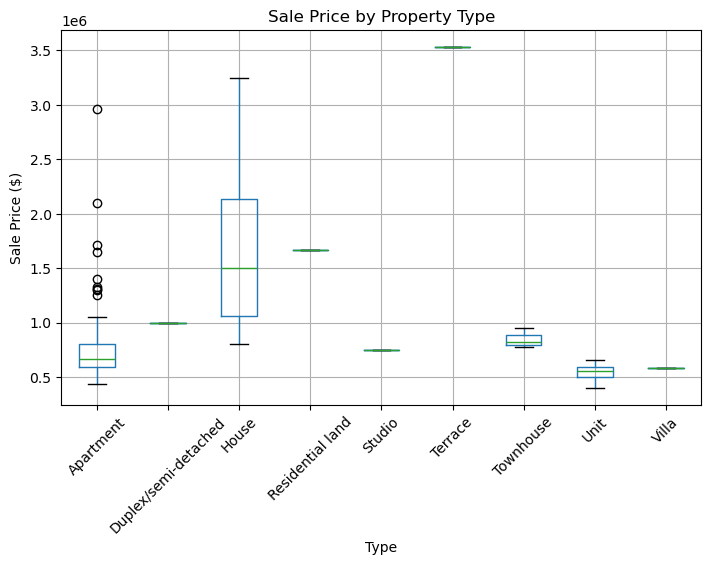

In [107]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='Sale Price', by='Type', ax=ax)
ax.set_ylabel('Sale Price ($)')
ax.set_title('Sale Price by Property Type')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

In [108]:
q1 = df['Sale Price'].quantile(0.25)
q3 = df['Sale Price'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = df[(df['Sale Price'] < lower) | (df['Sale Price'] > upper)]
outliers[['ID', 'Address', 'Suburb', 'Type', 'Sale Price']]

,ID,Address,Suburb,Type,Sale Price
16,PEN017,"172 Derby Street, Penrith",PEN,Residential land,1670000.0
72,SUR003,"8/70 Marlborough Street, Surry Hills",SUR,Apartment,1650000.0
75,SUR006,"11 Belvoir Street, Surry Hills",SUR,House,1500000.0
77,SUR008,"524 Crown Street, Surry Hills",SUR,Terrace,3530000.0
78,SUR009,"206 Devonshire Street, Surry Hills",SUR,House,1600000.0
85,SUR016,"61/5-13 Hutchinson Street, Surry Hills",SUR,Apartment,1710000.0
87,SUR018,"53 Marshall Street, Surry Hills",SUR,House,2310000.0
88,SUR019,"49 Waterloo Street, Surry Hills",SUR,House,3250000.0
89,SUR020,"1514/20 Pelican Street, Surry Hills",SUR,Apartment,2965000.0
95,SUR026,"5 Rainford Street, Surry Hills",SUR,House,2725000.0


In [109]:
numeric_corr = df[['Sale Price', 'Beds', 'Baths', 'Parking', 'Land / Size']].corr()['Sale Price'].sort_values(ascending=False)
numeric_corr

Sale Price     1.000000
Parking        0.606396
Beds           0.532010
Baths          0.280889
Land / Size    0.141630
Name: Sale Price, dtype: float64

## Part 2: Feature Engineering

In [110]:
df['Sale Year'] = df['Sale Date'].dt.year
df['Sale Month'] = df['Sale Date'].dt.month
df[['Sale Date', 'Sale Year', 'Sale Month']].head()

,Sale Date,Sale Year,Sale Month
0,2026-08-17,2026,8
1,2026-08-17,2026,8
2,2026-08-14,2026,8
3,2026-08-12,2026,8
4,2026-08-11,2026,8


## Part 3: Model Development and Evaluation

In [111]:
model_features = ['Suburb', 'Type', 'Beds', 'Baths', 'Parking', 'Sale Year', 'Sale Month']
X = df[model_features].copy()
y = df['Sale Price'].copy()
X.isnull().sum()

Suburb         0
Type           0
Beds           1
Baths          5
Parking       23
Sale Year      0
Sale Month     0
dtype: int64

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=X['Suburb']
)
print('Training samples:', len(X_train))
print('Test samples:', len(X_test))

Training samples: 84
Test samples: 21


In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = ['Beds', 'Baths', 'Parking', 'Sale Month']
categorical_features = ['Suburb', 'Type']

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [114]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

baseline = Pipeline([('preprocessor', preprocessor), ('model', DummyRegressor(strategy='mean'))])

baseline_scores = cross_validate(
    baseline, X_train, y_train, cv=kfold,
    scoring={'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}
)

print(f"Baseline CV MAE:  ${-baseline_scores['test_MAE'].mean():,.2f}")
print(f"Baseline CV RMSE: ${-baseline_scores['test_RMSE'].mean():,.2f}")
print(f"Baseline CV R2:   {baseline_scores['test_R2'].mean():.4f}")

Baseline CV MAE:  $382,544.76
Baseline CV RMSE: $550,633.54
Baseline CV R2:   -0.1914


In [115]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

linear_model = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42))
])

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=2, random_state=42))
])

In [116]:
models = {'Linear Regression': linear_model, 'Random Forest': rf_model, 'Gradient Boosting': gb_model}
model_results = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=kfold,
        scoring={'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
        return_train_score=True
    )
    model_results.append({
        'Model': name,
        'CV MAE': -scores['test_MAE'].mean(),
        'CV RMSE': -scores['test_RMSE'].mean(),
        'CV R2': scores['test_R2'].mean(),
        'Train R2': scores['train_R2'].mean()
    })

model_results_df = pd.DataFrame(model_results).sort_values('CV RMSE').reset_index(drop=True)
model_results_df.round(4)

,Model,CV MAE,CV RMSE,CV R2,Train R2
0,Linear Regression,230277.7002,333182.6378,0.5390,0.8515
1,Random Forest,187140.8308,341508.2614,0.6026,0.8663
2,Gradient Boosting,187843.4566,344163.1651,0.5643,0.9656


In [117]:
best_model = rf_model
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print(f"Test MAE:  ${test_mae:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Test R2:   {test_r2:.4f}")

Test MAE:  $176,527.12
Test RMSE: $306,461.28
Test R2:   0.7375


## Part 4: Investigating Prediction Failures

In [118]:
test_results = X_test.copy()
test_results['ID'] = df.loc[X_test.index, 'ID']
test_results['Address'] = df.loc[X_test.index, 'Address']
test_results['Actual Price'] = y_test
test_results['Predicted Price'] = y_pred
test_results['Error'] = test_results['Predicted Price'] - test_results['Actual Price']
test_results['Absolute Error'] = abs(test_results['Error'])
test_results = test_results.sort_values('Absolute Error', ascending=False)

top5 = test_results[[
    'ID', 'Address', 'Suburb', 'Type', 'Beds', 'Baths', 'Parking',
    'Actual Price', 'Predicted Price', 'Error', 'Absolute Error'
]].head(5)
top5

,ID,Address,Suburb,Type,Beds,Baths,Parking,Actual Price,Predicted Price,Error,Absolute Error
87,SUR018,"53 Marshall Street, Surry Hills",SUR,House,2.0,1.0,NaN,2310000.0,1.368284e+06,-941716.145345,941716.145345
95,SUR026,"5 Rainford Street, Surry Hills",SUR,House,3.0,1.0,NaN,2725000.0,2.011493e+06,-713506.504089,713506.504089
85,SUR016,"61/5-13 Hutchinson Street, Surry Hills",SUR,Apartment,2.0,2.0,1.0,1710000.0,1.120418e+06,-589581.996055,589581.996055
17,PEN018,"5 & 5A Holt Court, Penrith",PEN,House,5.0,2.0,2.0,1280000.0,1.549613e+06,269613.324074,269613.324074
60,PAR026,"28/24 Campbell Street, Parramatta",PAR,Apartment,2.0,2.0,1.0,500000.0,7.287306e+05,228730.575212,228730.575212


## Part 5: Human Judgement, Machine Learning, and Large Language Models

In [131]:
selected_ids = [
    'PAR008', 'PAR026', 'PAR029', 'PEN004', 'PEN007',
    'PEN018', 'SUR004', 'SUR010', 'SUR016', 'SUR018'
]

comparison = test_results[
    test_results['ID'].isin(selected_ids)
][
    [
        'ID', 'Address', 'Suburb', 'Type',
        'Beds', 'Baths', 'Parking',
        'Actual Price', 'Predicted Price'
    ]
].rename(
    columns={'Predicted Price': 'ML Prediction'}
).reset_index(drop=True)


claude_estimates = {
    'PAR008': 580000,
    'PAR026': 650000,
    'PAR029': 650000,
    'PEN004': 520000,
    'PEN007': 950000,
    'PEN018': 1150000,
    'SUR004': 750000,
    'SUR010': 800000,
    'SUR016': 1350000,
    'SUR018': 1900000
}


human_estimates = {
    'PAR008': 600000,
    'PAR026': 600000,
    'PAR029': 600000,
    'PEN004': 450000,
    'PEN007': 1000000,
    'PEN018': 1000000,
    'SUR004': 650000,
    'SUR010': 700000,
    'SUR016': 1400000,
    'SUR018': 2000000
}


comparison['LLM Estimate (Claude)'] = (
    comparison['ID'].map(claude_estimates)
)

comparison['Human Estimate'] = (
    comparison['ID'].map(human_estimates)
)


comparison['ML Abs Error'] = abs(
    comparison['ML Prediction'] -
    comparison['Actual Price']
)

comparison['LLM Abs Error'] = abs(
    comparison['LLM Estimate (Claude)'] -
    comparison['Actual Price']
)

comparison['Human Abs Error'] = abs(
    comparison['Human Estimate'] -
    comparison['Actual Price']
)


comparison

,ID,Address,Suburb,Type,Beds,Baths,Parking,Actual Price,ML Prediction,LLM Estimate (Claude),Human Estimate,ML Abs Error,LLM Abs Error,Human Abs Error
0,SUR018,"53 Marshall Street, Surry Hills",SUR,House,2.0,1.0,NaN,2310000.0,1.368284e+06,1900000,2000000,941716.145345,410000.0,310000.0
1,SUR016,"61/5-13 Hutchinson Street, Surry Hills",SUR,Apartment,2.0,2.0,1.0,1710000.0,1.120418e+06,1350000,1400000,589581.996055,360000.0,310000.0
2,PEN018,"5 & 5A Holt Court, Penrith",PEN,House,5.0,2.0,2.0,1280000.0,1.549613e+06,1150000,1000000,269613.324074,130000.0,280000.0
3,PAR026,"28/24 Campbell Street, Parramatta",PAR,Apartment,2.0,2.0,1.0,500000.0,7.287306e+05,650000,600000,228730.575212,150000.0,100000.0
4,SUR004,"61/2 Goodlet Street, Surry Hills",SUR,Apartment,1.0,1.0,NaN,622500.0,7.376713e+05,750000,650000,115171.268086,127500.0,27500.0
5,PEN004,"2/12 Thurston Street, Penrith",PEN,Apartment,2.0,1.0,1.0,510000.0,5.763617e+05,520000,450000,66361.656424,10000.0,60000.0
6,PAR029,"1702/1A Morton Street, Parramatta",PAR,Apartment,2.0,2.0,1.0,667000.0,7.287306e+05,650000,600000,61730.575212,17000.0,67000.0
7,PEN007,"28 Cooper Street, Penrith",PEN,House,3.0,2.0,1.0,1060000.0,1.014249e+06,950000,1000000,45750.580688,110000.0,60000.0
8,PAR008,"4/39 Great Western Highway, Parramatta",PAR,Unit,2.0,1.0,1.0,560000.0,5.412380e+05,580000,600000,18762.048168,20000.0,40000.0
9,SUR010,"71/679-695 Bourke Street, Surry Hills",SUR,Apartment,1.0,1.0,1.0,780000.0,7.833567e+05,800000,700000,3356.663784,20000.0,80000.0


In [132]:
summary = pd.DataFrame({
    'Approach': [
        'Random Forest',
        'Claude',
        'Human'
    ],
    'MAE': [
        comparison['ML Abs Error'].mean(),
        comparison['LLM Abs Error'].mean(),
        comparison['Human Abs Error'].mean()
    ],
    'Median Absolute Error': [
        comparison['ML Abs Error'].median(),
        comparison['LLM Abs Error'].median(),
        comparison['Human Abs Error'].median()
    ]
})

summary = summary.sort_values('MAE').reset_index(drop=True)

print(summary.round(2))

        Approach        MAE  Median Absolute Error
0          Human  133450.00               73500.00
1         Claude  135450.00              118750.00
2  Random Forest  234077.48               90766.46


In [133]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

actual = comparison['Actual Price']

predictions = {
    'Random Forest': comparison['ML Prediction'],
    'Claude': comparison['LLM Estimate (Claude)'],
    'Human': comparison['Human Estimate']
}

results = []

for name, prediction in predictions.items():

    mae = mean_absolute_error(actual, prediction)

    rmse = np.sqrt(
        mean_squared_error(actual, prediction)
    )

    r2 = r2_score(actual, prediction)

    results.append({
        'Approach': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

part5_results = pd.DataFrame(results)

print(part5_results.round(4))

        Approach          MAE         RMSE      R2
0  Random Forest  234077.4833  371938.2477  0.5792
1         Claude  135450.0000  191479.8292  0.8885
2          Human  133450.0000  173506.5561  0.9084


In [134]:
comparison['ML % Error'] = (
    comparison['ML Abs Error'] /
    comparison['Actual Price']
) * 100

comparison['LLM % Error'] = (
    comparison['LLM Abs Error'] /
    comparison['Actual Price']
) * 100

comparison['Human % Error'] = (
    comparison['Human Abs Error'] /
    comparison['Actual Price']
) * 100

In [135]:
comparison[
    [
        'ID',
        'Address',
        'Actual Price',
        'ML Prediction',
        'LLM Estimate (Claude)',
        'Human Estimate',
        'ML Abs Error',
        'LLM Abs Error',
        'Human Abs Error'
    ]
].round(2)

,ID,Address,Actual Price,ML Prediction,LLM Estimate (Claude),Human Estimate,ML Abs Error,LLM Abs Error,Human Abs Error
0,SUR018,"53 Marshall Street, Surry Hills",2310000.0,1368283.85,1900000,2000000,941716.15,410000.0,310000.0
1,SUR016,"61/5-13 Hutchinson Street, Surry Hills",1710000.0,1120418.00,1350000,1400000,589582.00,360000.0,310000.0
2,PEN018,"5 & 5A Holt Court, Penrith",1280000.0,1549613.32,1150000,1000000,269613.32,130000.0,280000.0
3,PAR026,"28/24 Campbell Street, Parramatta",500000.0,728730.58,650000,600000,228730.58,150000.0,100000.0
4,SUR004,"61/2 Goodlet Street, Surry Hills",622500.0,737671.27,750000,650000,115171.27,127500.0,27500.0
5,PEN004,"2/12 Thurston Street, Penrith",510000.0,576361.66,520000,450000,66361.66,10000.0,60000.0
6,PAR029,"1702/1A Morton Street, Parramatta",667000.0,728730.58,650000,600000,61730.58,17000.0,67000.0
7,PEN007,"28 Cooper Street, Penrith",1060000.0,1014249.42,950000,1000000,45750.58,110000.0,60000.0
8,PAR008,"4/39 Great Western Highway, Parramatta",560000.0,541237.95,580000,600000,18762.05,20000.0,40000.0
9,SUR010,"71/679-695 Bourke Street, Surry Hills",780000.0,783356.66,800000,700000,3356.66,20000.0,80000.0


In [136]:
comparison['Best Approach'] = comparison[
    [
        'ML Abs Error',
        'LLM Abs Error',
        'Human Abs Error'
    ]
].idxmin(axis=1)

comparison['Best Approach'] = comparison[
    'Best Approach'
].replace({
    'ML Abs Error': 'Random Forest',
    'LLM Abs Error': 'Claude',
    'Human Abs Error': 'Human'
})

print(
    comparison[
        [
            'ID',
            'Actual Price',
            'ML Abs Error',
            'LLM Abs Error',
            'Human Abs Error',
            'Best Approach'
        ]
    ].to_string(index=False)
)

    ID  Actual Price  ML Abs Error  LLM Abs Error  Human Abs Error Best Approach
SUR018     2310000.0 941716.145345       410000.0         310000.0         Human
SUR016     1710000.0 589581.996055       360000.0         310000.0         Human
PEN018     1280000.0 269613.324074       130000.0         280000.0        Claude
PAR026      500000.0 228730.575212       150000.0         100000.0         Human
SUR004      622500.0 115171.268086       127500.0          27500.0         Human
PEN004      510000.0  66361.656424        10000.0          60000.0        Claude
PAR029      667000.0  61730.575212        17000.0          67000.0        Claude
PEN007     1060000.0  45750.580688       110000.0          60000.0 Random Forest
PAR008      560000.0  18762.048168        20000.0          40000.0 Random Forest
SUR010      780000.0   3356.663784        20000.0          80000.0 Random Forest


In [137]:
print("\nNumber of properties won by each approach:")
print(comparison['Best Approach'].value_counts())


Number of properties won by each approach:
Best Approach
Human            4
Claude           3
Random Forest    3
Name: count, dtype: int64


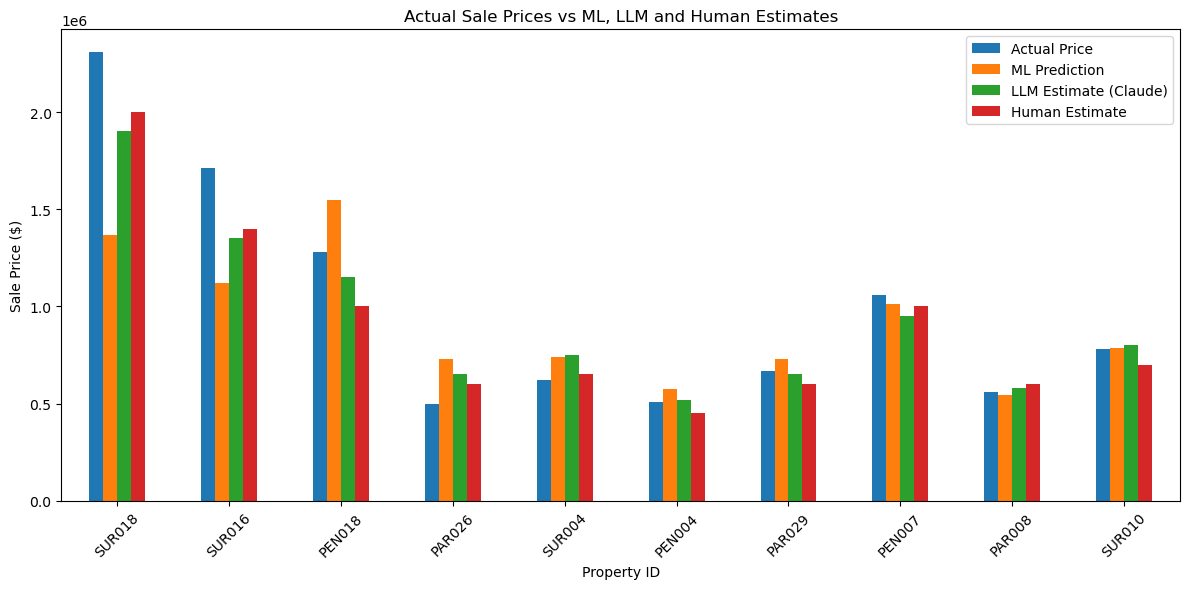

In [138]:
import matplotlib.pyplot as plt

plot_data = comparison.set_index('ID')[
    [
        'Actual Price',
        'ML Prediction',
        'LLM Estimate (Claude)',
        'Human Estimate'
    ]
]

plot_data.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.ylabel('Sale Price ($)')
plt.xlabel('Property ID')
plt.title('Actual Sale Prices vs ML, LLM and Human Estimates')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [139]:
bias = pd.DataFrame({
    'Approach': [
        'Random Forest',
        'Claude',
        'Human'
    ],
    'Mean Error': [
        (
            comparison['ML Prediction'] -
            comparison['Actual Price']
        ).mean(),

        (
            comparison['LLM Estimate (Claude)'] -
            comparison['Actual Price']
        ).mean(),

        (
            comparison['Human Estimate'] -
            comparison['Actual Price']
        ).mean()
    ]
})

print(bias.round(2))

        Approach  Mean Error
0  Random Forest   -85084.67
1         Claude   -69950.00
2          Human   -99950.00


## Part 6: Deployment

In [140]:
import joblib

joblib.dump(best_model, 'housing_price_model_final.pkl')
print('Model saved to housing_price_model_final.pkl')

Model saved to housing_price_model_final.pkl


## GenAI Acknowledgement

Claude was used during this project for independent price estimates in Part 5 and for limited assistance with code debugging and reviewing the project structure. All outputs were critically reviewed against the dataset and actual model results. The final code, analysis, interpretation and decisions are the author's own work.